In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
file_name = 'QUALITY & DEFECT REDUCTION.xlsx'
df = pd.read_csv(file_name)

In [4]:
df.head()

,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
0,2025-01-01 00:00:00,142,Plant_B,77.474270,2.604480,23.438160,315.443998,52,4,0
1,2025-01-01 01:00:00,124,Plant_C,72.435288,6.240213,30.236166,300.579876,89,1,0
2,2025-01-01 02:00:00,103,Plant_A,59.063863,6.470758,32.778778,240.961506,194,0,0
3,2025-01-01 03:00:00,108,Plant_C,63.859148,3.646682,26.077120,206.954154,190,2,0
4,2025-01-01 04:00:00,100,Plant_B,76.799275,5.261242,33.432417,259.130150,173,8,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          20000 non-null  object 
 1   MachineID          20000 non-null  int64  
 2   Plant              20000 non-null  object 
 3   Temperature        20000 non-null  float64
 4   Vibration          20000 non-null  float64
 5   Pressure           20000 non-null  float64
 6   EnergyConsumption  20000 non-null  float64
 7   ProductionUnits    20000 non-null  int64  
 8   DefectCount        20000 non-null  int64  
 9   MaintenanceFlag    20000 non-null  int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 1.5+ MB


In [6]:
df.describe()

,MachineID,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,124.699700,70.066527,4.998975,29.974246,249.873569,124.504200,2.994500,0.099200
std,14.462074,10.057316,1.490243,5.018546,39.774591,43.213092,1.722068,0.298938
min,100.000000,20.985152,-0.643926,10.851820,91.506259,50.000000,0.000000,0.000000
25%,112.000000,63.359851,4.002375,26.625467,222.692886,87.000000,2.000000,0.000000
50%,125.000000,70.069354,5.004583,29.978459,249.980463,125.000000,3.000000,0.000000
75%,137.000000,76.859156,5.996210,33.315192,276.770672,162.000000,4.000000,0.000000
max,149.000000,113.024267,10.393603,50.034469,448.340641,199.000000,11.000000,1.000000


In [7]:
features = ['Temperature', 'Vibration', 'Pressure', 'EnergyConsumption', 'ProductionUnits']
target = 'DefectCount'

X = df[features]
y = df[target]
X = X.fillna(X.mean())

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 3.19
R-squared (R2): -0.04



Feature Importances:
             Feature  Importance
1          Vibration    0.209931
3  EnergyConsumption    0.209646
2           Pressure    0.207317
0        Temperature    0.207123
4    ProductionUnits    0.165984


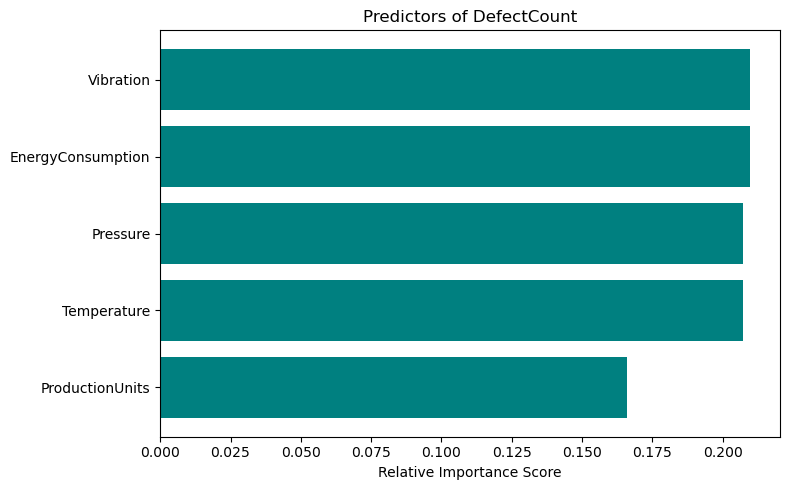

In [ ]:

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.gca().invert_yaxis() 
plt.xlabel('Relative Importance Score')
plt.title('Predictors of DefectCount')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

num_samples = 5
random_data = {
    'Temperature': np.random.uniform(20, 115, num_samples),
    'Vibration': np.random.uniform(0, 10, num_samples),
    'Pressure': np.random.uniform(10, 50, num_samples),
    'EnergyConsumption': np.random.uniform(90, 450, num_samples),
    'ProductionUnits': np.random.randint(50, 200, num_samples)
}
random_df = pd.DataFrame(random_data)
predicted_defects = model.predict(random_df)
random_df['Predicted_DefectCount'] = predicted_defects
random_df




,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,Predicted_DefectCount
0,27.426903,7.576776,37.829959,317.311161,90,2.88
1,41.212390,8.814693,34.613807,92.590114,159,3.16
2,94.723884,9.807430,44.329408,234.758320,96,3.98
3,36.057517,5.913597,25.124577,313.222730,73,3.28
4,61.627622,0.979822,24.104275,188.171409,115,3.42


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

poisson_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', PoissonRegressor())
])

param_grid = {
    'regressor__alpha': [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0],
    'regressor__max_iter': [100, 300, 500]
}

grid_search = GridSearchCV(
    estimator=poisson_model,
    param_grid=param_grid,
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print(f"Best Hyperparameters: {grid_search.best_params_}")

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\\nEvaluation Metrics on Test Set:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

coefficients = best_model.named_steps['regressor'].coef_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\\nFeature Coefficients (Impact on DefectCount):")
print(feature_importance_df)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Hyperparameters: {'regressor__alpha': 1.0, 'regressor__max_iter': 100}
\nEvaluation Metrics on Test Set:
Mean Squared Error (MSE): 3.05
Mean Absolute Error (MAE): 1.37
R-squared (R2): -0.00
\nFeature Coefficients (Impact on DefectCount):
             Feature  Coefficient
2           Pressure    -0.007278
3  EnergyConsumption     0.002834
4    ProductionUnits    -0.002521
0        Temperature     0.002090
1          Vibration    -0.001576


In [ ]:
import numpy as np
import pandas as pd

num_samples = 5
random_data = {
    'Temperature': np.random.uniform(20, 115, num_samples),
    'Vibration': np.random.uniform(0, 10, num_samples),
    'Pressure': np.random.uniform(10, 50, num_samples),
    'EnergyConsumption': np.random.uniform(90, 450, num_samples),
    'ProductionUnits': np.random.randint(50, 200, num_samples)
}
random_df = pd.DataFrame(random_data)

predicted_defects = best_model.predict(random_df)
random_df['Predicted_DefectCount'] = predicted_defects

random_df


,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,Predicted_DefectCount
0,33.259004,5.413061,39.456944,362.147964,160,2.945451
1,110.119296,1.821575,47.776412,331.072252,162,2.961410
2,105.930143,5.472974,10.245559,343.905522,52,3.135316
3,31.150696,3.805260,38.820886,147.192260,155,2.907782
4,42.375012,0.020193,42.547349,436.821259,109,2.979254
